In [1]:
import os
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from models import ImageClassifier, FCNet
from datasets import get_metadata, get_imagenet_stats
import json

In [30]:
# base_raw = 'spmll_raw/'
base_logic = r'results\multi_label_experiment_2025_09_14_21-03-27_pascal_no_constraints_fine_tuned_from_linear/'
base_logic = r'results\multi_label_experiment_2025_09_20_13-10-12_pascal_no_constraints_fine_tuned_from_linear_improved_loss/'
base_logic = r'results\multi_label_experiment_2025_09_20_16-21-18_pascal_no_constraints_fine_tuned_from_linear_improved_loss_update/'

In [80]:
base_logic = r'results\multi_label_experiment_2025_09_21_16-57-51_pascal/'
base_logic = r'results\multi_label_experiment_2025_09_21_16-17-37_pascal_cons/'

In [81]:
# Load params from a previous run
# with open(base_raw + 'params.json', 'r') as f:
#     RAW_P = json.load(f)
    
# Load params from a previous run
with open(base_logic + 'params.json', 'r') as f:
    LOGIC_P = json.load(f)

In [82]:
LOGIC_P

{'dataset': 'pascal',
 'loss': 'role_logics',
 'train_mode': 'linear_init',
 'val_set_variant': 'clean',
 'experiment_name': 'multi_label_experiment',
 'load_path': './data',
 'save_path': './results/multi_label_experiment_2025_09_21_16-17-37_pascal',
 'linear_init_lr': 0.001,
 'linear_init_bsize': 16,
 'lr_mult': 10.0,
 'stop_metric': 'map',
 'ls_coef': 0.1,
 'seed': 1200,
 'use_pretrained': True,
 'num_workers': 1,
 'split_seed': 1200,
 'val_frac': 0.2,
 'ss_seed': 999,
 'ss_frac_train': 1.0,
 'ss_frac_val': 1.0,
 'train_set_variant': 'observed',
 'num_epochs': 25,
 'freeze_feature_extractor': True,
 'use_feats': True,
 'arch': 'linear',
 'feature_extractor_arch': 'resnet50',
 'feat_dim': 2048,
 'expected_num_pos': 1.5,
 'train_feats_file': './data/pascal/train_features_imagenet_resnet50.npy',
 'val_feats_file': './data/pascal/val_features_imagenet_resnet50.npy',
 'bsize': 16,
 'lr': 0.001,
 'num_classes': 23}

In [83]:
mean, std = get_imagenet_stats()
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load category labels
category_map = {
    0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle',
    5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow',
    10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike', 14: 'person',
    15: 'pottedplant', 16: 'sheep', 17: 'sofa', 18: 'train', 19: 'tvmonitor', 20: "vehicle", 21: "animal", 22: "indoor"
}

In [84]:
LOGIC_P['arch'] = 'resnet50' 

In [85]:
# # Match saved model exactly
# r_linear_classifier = FCNet(RAW_P['feat_dim'], RAW_P['num_classes'])
# r_model = ImageClassifier(RAW_P, model_linear_classifier=r_linear_classifier)
# r_model.load_state_dict(torch.load(base_raw + 'best_model_state_f.pt', map_location='cpu'))
# r_model.eval()

In [86]:
# Match saved model exactly
LOGIC_P['arch'] = 'resnet50'

l_linear_classifier = FCNet(LOGIC_P['feat_dim'], LOGIC_P['num_classes'])
l_model = ImageClassifier(LOGIC_P, model_linear_classifier=l_linear_classifier)

# FIX: Add strict=False to ignore the missing feature extractor keys
l_model.load_state_dict(torch.load(base_logic + 'best_model_state_f.pt', map_location='cpu'), strict=False)

l_model.eval()

initializing image classifier
feature extractor: imagenet pretrained


c:\Users\ibrah\Workspace\T\spmll\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ibrah\Workspace\T\spmll\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


feature extractor frozen
linear classifier layer: specified by user


C:\Users\ibrah\AppData\Local\Temp\ipykernel_13064\2900169635.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  l_model.load_state_dict(torch.load(base_logic + 'best_model_

ImageClassifier(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
        

In [87]:
import requests
from PIL import Image
from io import BytesIO

# URL of the online image
img_url = "https://m.media-amazon.com/images/I/818zfBc5Q5L._AC_UF894,1000_QL80_.jpg"
img_url_2 = 'https://en.bernkastel.de/fileadmin/_processed_/b/f/csm_Rad_Peron_Sommer_Mosel_Weinberg_67090e3258.jpg'
img_url_3 = 'https://preview.redd.it/government-consult-on-allowing-motorcycles-to-access-bus-v0-d1m8815gowoc1.png?width=372&format=png&auto=webp&s=181b904e44aa254d3841b4f66e12cfd09477ce3c'
# Load image from URL
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert('RGB')

# Preprocess
input_tensor = transform(img).unsqueeze(0)  # shape: [1, 3, 448, 448]

In [88]:
input_tensor

tensor([[[[ 1.9064,  1.9578,  1.8893,  ...,  0.0569,  0.3994,  0.9474],
          [ 1.9578,  1.9920,  1.9920,  ...,  0.7762,  0.9817,  1.0673],
          [ 2.0092,  1.9578,  1.9407,  ...,  0.5364,  0.3309,  0.7419],
          ...,
          [ 0.3481,  0.0398, -0.0801,  ..., -0.4054, -0.3369, -0.1828],
          [-0.0629,  0.3652,  0.3652,  ..., -0.3027, -0.3198, -0.2342],
          [ 0.0912, -0.3712,  0.3138,  ..., -0.2342, -0.1486, -0.2342]],

         [[ 2.0784,  2.1310,  2.0609,  ...,  0.1527,  0.5203,  1.0805],
          [ 2.1310,  2.1660,  2.1660,  ...,  0.9055,  1.1155,  1.1856],
          [ 2.1835,  2.1310,  2.1134,  ...,  0.6604,  0.4503,  0.8704],
          ...,
          [ 0.1702, -0.1450, -0.2675,  ..., -0.6001, -0.5301, -0.3725],
          [-0.2500,  0.1877,  0.1877,  ..., -0.4951, -0.5126, -0.4251],
          [-0.0924, -0.5651,  0.1352,  ..., -0.4251, -0.3375, -0.4251]],

         [[ 2.2914,  2.3437,  2.2740,  ...,  0.0082,  0.2696,  0.8448],
          [ 2.3437,  2.3786,  

In [89]:
input_tensor = transform(img).unsqueeze(0) 
with torch.no_grad():
    # r_logits = r_model(input_tensor)
    # r_probs = torch.sigmoid(r_logits).squeeze(0)  # shape: (20,)
    
    l_logits = l_model(input_tensor)
    l_probs = torch.sigmoid(l_logits).squeeze(0)  # shape: (20,)


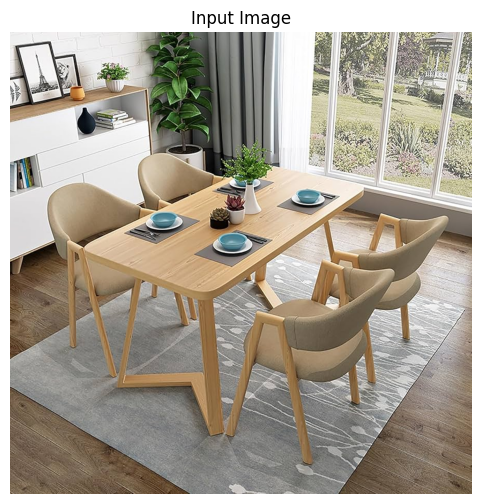

,Class,Logic Model Probability
0,aeroplane,0.022304
1,bicycle,0.052675
2,bird,0.033297
3,boat,0.051811
4,bottle,0.083912
5,bus,0.065580
6,car,0.031362
7,cat,0.043326
8,chair,0.797718
9,cow,0.067342


In [90]:
import matplotlib.pyplot as plt

# Show image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Input Image", fontsize=12)
plt.show()

# VOC class names
class_names = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor', "vehicle", "animal", "indoor"
]

import pandas as pd 

df = pd.DataFrame({
    'Class': class_names,
    # 'Raw Model Probability': r_probs.numpy(),
    'Logic Model Probability': l_probs.numpy()
})
df

In [91]:
val_images = np.load(r"data/pascal/formatted_val_images.npy")
val_labels = np.load(r"data/pascal/formatted_val_labels.npy")
val_labels_obs = np.load(r"data/pascal/formatted_val_labels_obs.npy")
val_images[0], val_labels[0], val_labels_obs[0]

(np.str_('2008_000002.jpg'),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 1.], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0.], dtype=float32))

In [92]:
from PIL import Image

class_names = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor', "vehicle", "animal", "indoor"
]


val_images = np.load(r"data/pascal/formatted_val_images.npy")
val_labels = np.load(r"data/pascal/formatted_val_labels.npy")
val_labels_obs = np.load(r"data/pascal/formatted_val_labels_obs.npy")

img_path = r"data/pascal/VOCdevkit/VOC2012/JPEGImages/" + val_images[0]
img = Image.open(img_path).convert("RGB")


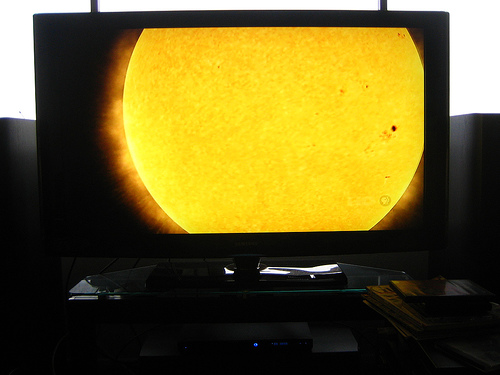

In [93]:
img

In [94]:
import os
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_fscore_support, f1_score, precision_score, recall_score,
    accuracy_score, hamming_loss
)

# ---- Inputs you already have ----
# class_names = [...]
# val_images, val_labels, val_labels_obs = np.load(...)
# transform, l_model defined elsewhere

IMG_DIR = r"data/pascal/VOCdevkit/VOC2012/JPEGImages/"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
l_model = l_model.to(DEVICE).eval()

# ---------- 1) Get probabilities for ALL validation images ----------
def predict_all_probs(img_names, batch_size=16, threshold=None):
    """
    Returns:
        y_scores: (N, C) float array of probabilities
    """
    N = len(img_names)
    # Peek one image to get C
    first_img = Image.open(os.path.join(IMG_DIR, img_names[0])).convert("RGB")
    with torch.no_grad():
        C = l_model(transform(first_img).unsqueeze(0).to(DEVICE)).shape[-1]

    y_scores = np.zeros((N, C), dtype=np.float32)

    # Simple batching without DataLoader
    for start in tqdm(range(0, N, batch_size), desc="Predicting"):
        end = min(start + batch_size, N)
        batch_imgs = []
        for i in range(start, end):
            p = os.path.join(IMG_DIR, img_names[i])
            img = Image.open(p).convert("RGB")
            batch_imgs.append(transform(img))
        batch_tensor = torch.stack(batch_imgs, dim=0).to(DEVICE)

        with torch.no_grad():
            logits = l_model(batch_tensor)
            probs = torch.sigmoid(logits).cpu().numpy()
        y_scores[start:end] = probs

    return y_scores

# Ensure filenames are strings (sometimes np.load yields bytes)
val_files = [fn.decode() if isinstance(fn, bytes) else str(fn) for fn in val_images]
y_true = val_labels.astype(int)             # shape (N, C)
y_scores = predict_all_probs(val_files, batch_size=16)

# ---------- 2) Compute metrics ----------
def multilabel_metrics(y_true, y_scores, class_names, threshold=0.5):
    """
    Computes:
      - Per-class: AP, AUROC, Precision, Recall, F1 (at threshold)
      - Overall: mAP (macro), AP-micro, AUROC-macro, AUROC-micro,
                 Precision/Recall/F1 (micro & macro at threshold),
                 Subset Accuracy, Hamming Loss
    """
    N, C = y_true.shape
    assert C == len(class_names), "class_names length must match labels"

    # Per-class AP & AUROC (use probabilities)
    ap_per_class = []
    auroc_per_class = []
    for c in range(C):
        y_c = y_true[:, c]
        s_c = y_scores[:, c]
        # average_precision_score works even with class imbalance
        ap_c = average_precision_score(y_c, s_c) if (y_c.max() != y_c.min()) else np.nan
        # roc_auc_score requires both classes present
        try:
            auc_c = roc_auc_score(y_c, s_c)
        except ValueError:
            auc_c = np.nan
        ap_per_class.append(ap_c)
        auroc_per_class.append(auc_c)

    # Threshold to get binary predictions
    y_pred = (y_scores >= threshold).astype(int)

    # Per-class P/R/F1 at threshold
    prec_c, rec_c, f1_c, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )

    # Overall (micro/macro)
    map_macro = np.nanmean(ap_per_class)
    ap_micro  = average_precision_score(y_true, y_scores, average="micro")
    auroc_macro = np.nanmean(auroc_per_class)
    # For AUROC micro, flatten
    try:
        auroc_micro = roc_auc_score(y_true.ravel(), y_scores.ravel())
    except ValueError:
        auroc_micro = np.nan

    p_micro = precision_score(y_true, y_pred, average="micro", zero_division=0)
    r_micro = recall_score(y_true, y_pred, average="micro", zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)

    p_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    r_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    subset_acc = accuracy_score(y_true, y_pred)  # exact match ratio
    hamming = hamming_loss(y_true, y_pred)

    # Build per-class table
    per_class_df = pd.DataFrame({
        "Class": class_names,
        "AP": ap_per_class,
        "AUROC": auroc_per_class,
        "Precision@{:.2f}".format(threshold): prec_c,
        "Recall@{:.2f}".format(threshold): rec_c,
        "F1@{:.2f}".format(threshold): f1_c,
        "Support": y_true.sum(axis=0)
    })

    # Overall summary
    overall = {
        "mAP (macro mean AP)": map_macro,
        "AP (micro)": ap_micro,
        "AUROC (macro mean)": auroc_macro,
        "AUROC (micro)": auroc_micro,
        "Precision (micro)@{:.2f}".format(threshold): p_micro,
        "Recall (micro)@{:.2f}".format(threshold): r_micro,
        "F1 (micro)@{:.2f}".format(threshold): f1_micro,
        "Precision (macro)@{:.2f}".format(threshold): p_macro,
        "Recall (macro)@{:.2f}".format(threshold): r_macro,
        "F1 (macro)@{:.2f}".format(threshold): f1_macro,
        "Subset Accuracy": subset_acc,
        "Hamming Loss": hamming,
    }

    overall_df = pd.DataFrame(list(overall.items()), columns=["Metric", "Value"])
    return per_class_df, overall_df, y_pred

per_class_df, overall_df, y_pred = multilabel_metrics(y_true, y_scores, class_names, threshold=0.5)

print("\n=== Overall Metrics ===")
print(overall_df.to_string(index=False))

print("\n=== Per-class Metrics ===")
print(per_class_df.sort_values("AP", ascending=False).to_string(index=False))


Predicting: 100%|██████████| 364/364 [00:52<00:00,  7.00it/s]



=== Overall Metrics ===
                Metric    Value
   mAP (macro mean AP) 0.870523
            AP (micro) 0.918551
    AUROC (macro mean) 0.973397
         AUROC (micro) 0.980807
Precision (micro)@0.50 0.906775
   Recall (micro)@0.50 0.778051
       F1 (micro)@0.50 0.837496
Precision (macro)@0.50 0.917424
   Recall (macro)@0.50 0.668335
       F1 (macro)@0.50 0.756962
       Subset Accuracy 0.523957
          Hamming Loss 0.031143

=== Per-class Metrics ===
      Class       AP    AUROC  Precision@0.50  Recall@0.50  F1@0.50  Support
     animal 0.992695 0.995024        0.965882     0.959885 0.962874     2094
  aeroplane 0.991926 0.999046        0.996711     0.883382 0.936631      343
    vehicle 0.980719 0.987524        0.908649     0.945878 0.926890     1977
        cat 0.974162 0.992773        0.976645     0.850277 0.909091      541
      train 0.969307 0.997270        0.995370     0.793358 0.882957      271
     person 0.940844 0.955137        0.918246     0.810320 0.860914   

In [ ]:
# Without constraints 

# Predicting: 100%|██████████| 364/364 [00:56<00:00,  6.47it/s]

# === Overall Metrics ===
#                 Metric    Value
#    mAP (macro mean AP) 0.869018
#             AP (micro) 0.917561
#     AUROC (macro mean) 0.971940
#          AUROC (micro) 0.978576
# Precision (micro)@0.50 0.921434
#    Recall (micro)@0.50 0.764949
#        F1 (micro)@0.50 0.835931
# Precision (macro)@0.50 0.914205
#    Recall (macro)@0.50 0.673329
#        F1 (macro)@0.50 0.762108
#        Subset Accuracy 0.544393
#           Hamming Loss 0.030972

# === Per-class Metrics ===
#       Class       AP    AUROC  Precision@0.50  Recall@0.50  F1@0.50  Support
#      animal 0.989598 0.993004        0.960444     0.950812 0.955604     2094
#   aeroplane 0.989071 0.998519        0.951289     0.967930 0.959538      343
#     vehicle 0.977465 0.984968        0.952153     0.905918 0.928460     1977
#         cat 0.974572 0.992639        0.982495     0.829945 0.899800      541
#       train 0.972593 0.997349        1.000000     0.756458 0.861345      271
#        bird 0.942015 0.982372        0.962500     0.832432 0.892754      370
#      person 0.941852 0.955251        0.934352     0.788820 0.855440     2093
#         dog 0.935328 0.987331        0.956989     0.680428 0.795353      654
#         bus 0.928549 0.983356        0.959770     0.802885 0.874346      208
#       horse 0.918156 0.989944        0.943590     0.751020 0.836364      245
#   motorbike 0.915757 0.986784        0.920930     0.758621 0.831933      261
#       sheep 0.903904 0.988391        1.000000     0.610390 0.758065      154
#        boat 0.894039 0.984831        0.928962     0.685484 0.788863      248
#     bicycle 0.889623 0.973692        0.951087     0.616197 0.747863      284
#      indoor 0.887631 0.946595        0.846890     0.762931 0.802721     1392
#   tvmonitor 0.880235 0.979981        0.956044     0.610526 0.745182      285
#         cow 0.863782 0.990581        0.923913     0.559211 0.696721      152
#         car 0.810062 0.954573        0.731579     0.730298 0.730938      571
#       chair 0.754253 0.948962        0.819767     0.509946 0.628763      553
# diningtable 0.694633 0.961286        0.829545     0.271375 0.408964      269
#      bottle 0.682306 0.919953        0.915493     0.381232 0.538302      341
#        sofa 0.668753 0.932184        0.876289     0.340000 0.489914      250
# pottedplant 0.573247 0.922064        0.722628     0.383721 0.501266      258

In [ ]:
Predicting: 100%|██████████| 364/364 [00:56<00:00,  6.47it/s]

=== Overall Metrics ===
                Metric    Value
   mAP (macro mean AP) 0.869018
            AP (micro) 0.917561
    AUROC (macro mean) 0.971940
         AUROC (micro) 0.978576
Precision (micro)@0.50 0.921434
   Recall (micro)@0.50 0.764949
       F1 (micro)@0.50 0.835931
Precision (macro)@0.50 0.914205
   Recall (macro)@0.50 0.673329
       F1 (macro)@0.50 0.762108
       Subset Accuracy 0.544393
          Hamming Loss 0.030972

=== Per-class Metrics ===
      Class       AP    AUROC  Precision@0.50  Recall@0.50  F1@0.50  Support
     animal 0.989598 0.993004        0.960444     0.950812 0.955604     2094
  aeroplane 0.989071 0.998519        0.951289     0.967930 0.959538      343
    vehicle 0.977465 0.984968        0.952153     0.905918 0.928460     1977
        cat 0.974572 0.992639        0.982495     0.829945 0.899800      541
      train 0.972593 0.997349        1.000000     0.756458 0.861345      271
       bird 0.942015 0.982372        0.962500     0.832432 0.892754      370
     person 0.941852 0.955251        0.934352     0.788820 0.855440     2093
        dog 0.935328 0.987331        0.956989     0.680428 0.795353      654
        bus 0.928549 0.983356        0.959770     0.802885 0.874346      208
      horse 0.918156 0.989944        0.943590     0.751020 0.836364      245
  motorbike 0.915757 0.986784        0.920930     0.758621 0.831933      261
      sheep 0.903904 0.988391        1.000000     0.610390 0.758065      154
       boat 0.894039 0.984831        0.928962     0.685484 0.788863      248
    bicycle 0.889623 0.973692        0.951087     0.616197 0.747863      284
     indoor 0.887631 0.946595        0.846890     0.762931 0.802721     1392
  tvmonitor 0.880235 0.979981        0.956044     0.610526 0.745182      285
        cow 0.863782 0.990581        0.923913     0.559211 0.696721      152
        car 0.810062 0.954573        0.731579     0.730298 0.730938      571
      chair 0.754253 0.948962        0.819767     0.509946 0.628763      553
diningtable 0.694633 0.961286        0.829545     0.271375 0.408964      269
     bottle 0.682306 0.919953        0.915493     0.381232 0.538302      341
       sofa 0.668753 0.932184        0.876289     0.340000 0.489914      250
pottedplant 0.573247 0.922064        0.722628     0.383721 0.501266      258

In [ ]:
# Predicting: 100%|██████████| 182/182 [00:52<00:00,  3.48it/s]
# === Overall Metrics ===
#                 Metric    Value
#    mAP (macro mean AP) 0.876865
#             AP (micro) 0.924008
#     AUROC (macro mean) 0.976366
#          AUROC (micro) 0.982715
# Precision (micro)@0.50 0.914164
#    Recall (micro)@0.50 0.777906
#        F1 (micro)@0.50 0.840549
# Precision (macro)@0.50 0.908879
#    Recall (macro)@0.50 0.670905
#        F1 (macro)@0.50 0.754704
#        Subset Accuracy 0.534261
#           Hamming Loss 0.030442

# === Per-class Metrics ===
#       Class       AP    AUROC  Precision@0.50  Recall@0.50  F1@0.50  Support
#      animal 0.993605 0.994720        0.990977     0.944126 0.966985     2094
#   aeroplane 0.986434 0.998658        0.996364     0.798834 0.886731      343
#     vehicle 0.982151 0.987750        0.942974     0.936773 0.939863     1977
#         cat 0.969327 0.991171        0.956088     0.885397 0.919386      541
#       train 0.958824 0.995697        0.899628     0.892989 0.896296      271
#      person 0.957269 0.967330        0.951532     0.816054 0.878601     2093
#        bird 0.955130 0.985735        1.000000     0.664865 0.798701      370
#         bus 0.946858 0.992900        0.988304     0.812500 0.891821      208
#         dog 0.935951 0.985668        0.930783     0.781346 0.849543      654
#   motorbike 0.912504 0.987045        0.834615     0.831418 0.833013      261
#       horse 0.908719 0.989046        0.963190     0.640816 0.769608      245
#      indoor 0.907579 0.958269        0.743202     0.883621 0.807351     1392
#       sheep 0.903891 0.981411        0.988235     0.545455 0.702929      154
#        boat 0.894150 0.982719        0.957576     0.637097 0.765133      248
#   tvmonitor 0.891735 0.986068        0.960894     0.603509 0.741379      285
#         cow 0.875967 0.994781        0.746835     0.776316 0.761290      152
#     bicycle 0.873691 0.966362        0.992424     0.461268 0.629808      284
#         car 0.853740 0.959780        0.920635     0.609457 0.733404      571
#       chair 0.766754 0.954669        0.846875     0.490054 0.620848      553
#        sofa 0.694872 0.958687        0.830508     0.392000 0.532609      250
# diningtable 0.690416 0.971655        0.781818     0.319703 0.453826      269
#      bottle 0.668213 0.935554        0.780749     0.428152 0.553030      341
# pottedplant 0.640122 0.930753        0.900000     0.279070 0.426036      258

In [44]:
import torch
from torch import nn
from ccn.constraints_layer import ConstraintsLayer
from ccn.constraints_group import ConstraintsGroup
from ccn.constraint import Constraint
from ccn.clauses_group import ClausesGroup

rules_path = "rules.txt"
group   = ConstraintsGroup(rules_path)
clauses = ClausesGroup.from_constraints_group(group)
layer   = ConstraintsLayer.from_clauses_group(clauses, num_classes=23, centrality="katz")

<generator object ConstraintsGroup.__init__.<locals>.<genexpr> at 0x000001D6751F2AB0>


In [46]:
id2name = {
    0:'aeroplane',1:'bicycle',2:'bird',3:'boat',4:'bottle',
    5:'bus',6:'car',7:'cat',8:'chair',9:'cow',
    10:'diningtable',11:'dog',12:'horse',13:'motorbike',14:'person',
    15:'pottedplant',16:'sheep',17:'sofa',18:'train',19:'tvmonitor', 20:'vehicle', 21:'animal', 22:'indoor'
}


In [ ]:
# with constraints but without consistency loss 
# Predicting: 100%|██████████| 182/182 [01:10<00:00,  2.60it/s]

# === Overall Metrics ===
#                 Metric    Value
#    mAP (macro mean AP) 0.870627
#             AP (micro) 0.917414
#     AUROC (macro mean) 0.971547
#          AUROC (micro) 0.976299
# Precision (micro)@0.50 0.952273
#    Recall (micro)@0.50 0.727957
#        F1 (micro)@0.50 0.825142
# Precision (macro)@0.50 0.945013
#    Recall (macro)@0.50 0.626025
#        F1 (macro)@0.50 0.725086
#        Subset Accuracy 0.542847
#           Hamming Loss 0.031823

# === Per-class Metrics ===
#       Class       AP    AUROC  Precision@0.50  Recall@0.50  F1@0.50  Support
#      animal 0.993386 0.995019        0.980019     0.960363 0.970092     2094
#   aeroplane 0.990645 0.999123        0.987730     0.938776 0.962631      343
#     vehicle 0.977642 0.985427        0.917368     0.937785 0.927464     1977
#         cat 0.976107 0.995049        0.979123     0.866913 0.919608      541
#       train 0.962339 0.995403        0.994924     0.723247 0.837607      271
#        bird 0.956747 0.983618        0.986799     0.808108 0.888559      370
#      person 0.956486 0.964809        0.983461     0.738653 0.843656     2093
#         dog 0.941809 0.983349        0.992208     0.584098 0.735322      654
#       horse 0.914603 0.990500        0.908654     0.771429 0.834437      245
#         bus 0.911244 0.974177        0.987879     0.783654 0.873995      208
#       sheep 0.906014 0.982627        0.988764     0.571429 0.724280      154
#      indoor 0.903215 0.951024        0.916900     0.705460 0.797402     1392
#        boat 0.894771 0.984651        0.905000     0.729839 0.808036      248
#         cow 0.894717 0.995136        0.894737     0.671053 0.766917      152
#   motorbike 0.892970 0.977951        0.901478     0.701149 0.788793      261
#     bicycle 0.877866 0.960175        1.000000     0.408451 0.580000      284
#   tvmonitor 0.865257 0.984188        0.928571     0.638596 0.756757      285
#         car 0.861313 0.953121        0.924020     0.660245 0.770174      571
#       chair 0.736639 0.945314        0.894118     0.274864 0.420470      553
#        sofa 0.675460 0.944335        0.916667     0.220000 0.354839      250
# diningtable 0.668938 0.956574        0.867925     0.171004 0.285714      269
#      bottle 0.640590 0.924683        0.923077     0.281525 0.431461      341
# pottedplant 0.625665 0.919339        0.955882     0.251938 0.398773      258

Without constraints 

Predicting: 100%|██████████| 182/182 [00:52<00:00,  3.45it/s]

=== Overall Metrics ===
                Metric    Value
   mAP (macro mean AP) 0.872812
            AP (micro) 0.919836
    AUROC (macro mean) 0.972352
         AUROC (micro) 0.978147
Precision (micro)@0.50 0.950177
   Recall (micro)@0.50 0.720646
       F1 (micro)@0.50 0.819645
Precision (macro)@0.50 0.939294
   Recall (macro)@0.50 0.625373
       F1 (macro)@0.50 0.731754
       Subset Accuracy 0.538382
          Hamming Loss 0.032711

=== Per-class Metrics ===
      Class       AP    AUROC  Precision@0.50  Recall@0.50  F1@0.50  Support
     animal 0.988945 0.990800        0.990865     0.880611 0.932491     2094
  aeroplane 0.984532 0.998676        0.981132     0.909621 0.944024      343
    vehicle 0.971356 0.982643        0.936249     0.898837 0.917161     1977
      train 0.966901 0.996726        1.000000     0.778598 0.875519      271
        cat 0.964914 0.990762        0.967880     0.835490 0.896825      541
       bird 0.957382 0.984230        0.996564     0.783784 0.877458      370
     person 0.955987 0.965040        0.948634     0.829431 0.885037     2093
        dog 0.940947 0.985380        0.968815     0.712538 0.821145      654
        bus 0.930664 0.990035        1.000000     0.600962 0.750751      208
        cow 0.908499 0.994755        0.968750     0.611842 0.750000      152
       boat 0.899620 0.982548        0.977901     0.713710 0.825175      248
      horse 0.898948 0.985514        0.969925     0.526531 0.682540      245
      sheep 0.898677 0.989724        0.920000     0.746753 0.824373      154
  tvmonitor 0.896932 0.986934        0.923445     0.677193 0.781377      285
  motorbike 0.891181 0.979484        0.917098     0.678161 0.779736      261
     indoor 0.881844 0.941578        0.908350     0.640805 0.751474     1392
    bicycle 0.874306 0.968020        0.969231     0.443662 0.608696      284
        car 0.830128 0.953094        0.907563     0.567426 0.698276      571
      chair 0.733919 0.938057        0.899408     0.274864 0.421053      553
     bottle 0.718790 0.937791        0.889535     0.448680 0.596491      341
       sofa 0.705380 0.957310        0.832000     0.416000 0.554667      250
diningtable 0.666236 0.958539        0.840000     0.156134 0.263323      269
pottedplant 0.608594 0.906464        0.890411     0.251938 0.392749      258


with 
Predicting: 100%|██████████| 182/182 [00:51<00:00,  3.52it/s]
=== Overall Metrics ===
                Metric    Value
   mAP (macro mean AP) 0.874732
            AP (micro) 0.920972
    AUROC (macro mean) 0.972885
         AUROC (micro) 0.979144
Precision (micro)@0.50 0.942498
   Recall (micro)@0.50 0.743955
       F1 (micro)@0.50 0.831540
Precision (macro)@0.50 0.947779
   Recall (macro)@0.50 0.624171
       F1 (macro)@0.50 0.730112
       Subset Accuracy 0.537524
          Hamming Loss 0.031091

=== Per-class Metrics ===
      Class       AP    AUROC  Precision@0.50  Recall@0.50  F1@0.50  Support
     animal 0.992849 0.994243        0.977362     0.948424 0.962676     2094
  aeroplane 0.991047 0.999237        0.993289     0.862974 0.923557      343
    vehicle 0.978185 0.984433        0.919052     0.941831 0.930302     1977
        cat 0.971976 0.992595        0.975930     0.824399 0.893788      541
      train 0.961957 0.996234        0.982222     0.815498 0.891129      271
     person 0.957730 0.967068        0.927975     0.849498 0.887004     2093
       bird 0.951926 0.982240        1.000000     0.667568 0.800648      370
        dog 0.939170 0.983054        0.971074     0.718654 0.826011      654
        bus 0.931333 0.987525        0.993590     0.745192 0.851648      208
      horse 0.916613 0.990190        0.975610     0.653061 0.782396      245
  motorbike 0.914544 0.981290        0.935323     0.720307 0.813853      261
     indoor 0.909888 0.954589        0.896610     0.760057 0.822706     1392
       boat 0.904622 0.982106        0.980519     0.608871 0.751244      248
      sheep 0.900358 0.981557        0.969697     0.623377 0.758893      154
    bicycle 0.887313 0.972406        1.000000     0.362676 0.532300      284
  tvmonitor 0.883851 0.982083        0.972789     0.501754 0.662037      285
        cow 0.881328 0.993727        0.929293     0.605263 0.733068      152
        car 0.828114 0.942149        0.961165     0.520140 0.675000      571
      chair 0.720775 0.935438        0.941176     0.289331 0.442600      553
       sofa 0.687987 0.945582        0.882979     0.332000 0.482558      250
     bottle 0.681448 0.920569        0.989796     0.284457 0.441913      341
diningtable 0.663293 0.962309        0.894737     0.189591 0.312883      269
pottedplant 0.662534 0.945730        0.728723     0.531008 0.614350      258

Predicting: 100%|██████████| 182/182 [00:53<00:00,  3.39it/s]
=== Overall Metrics ===
                Metric    Value
   mAP (macro mean AP) 0.871850
            AP (micro) 0.918579
    AUROC (macro mean) 0.974405
         AUROC (micro) 0.975456
Precision (micro)@0.50 0.945436
   Recall (micro)@0.50 0.732518
       F1 (micro)@0.50 0.825468
Precision (macro)@0.50 0.931927
   Recall (macro)@0.50 0.642715
       F1 (macro)@0.50 0.747715
       Subset Accuracy 0.559677
          Hamming Loss 0.031950

=== Per-class Metrics ===
      Class       AP    AUROC  Precision@0.50  Recall@0.50  F1@0.50  Support
  aeroplane 0.989295 0.998306        0.996721     0.886297 0.938272      343
     animal 0.988992 0.992459        0.951636     0.958453 0.955032     2094
        cat 0.978373 0.994557        0.978495     0.841035 0.904573      541
    vehicle 0.968770 0.979942        0.940863     0.893273 0.916450     1977
     person 0.962318 0.971246        0.964833     0.812709 0.882261     2093
      train 0.958987 0.995938        0.985075     0.730627 0.838983      271
       bird 0.950206 0.982256        0.996491     0.767568 0.867176      370
        dog 0.940481 0.988217        0.937729     0.782875 0.853333      654
        bus 0.926358 0.990632        0.981366     0.759615 0.856369      208
      horse 0.926312 0.990960        0.966102     0.697959 0.810427      245
      sheep 0.910793 0.986524        0.939655     0.707792 0.807407      154
  motorbike 0.904755 0.981971        0.959538     0.636015 0.764977      261
       boat 0.893447 0.980566        0.963190     0.633065 0.763990      248
    bicycle 0.883707 0.970756        0.943820     0.591549 0.727273      284
        cow 0.880593 0.993611        0.907407     0.644737 0.753846      152
  tvmonitor 0.866540 0.962061        0.972603     0.498246 0.658933      285
     indoor 0.859649 0.929960        0.916188     0.573276 0.705259     1392
        car 0.837805 0.956472        0.901515     0.625219 0.738366      571
      chair 0.755326 0.945522        0.943503     0.301989 0.457534      553
       sofa 0.701023 0.962034        0.807692     0.420000 0.552632      250
     bottle 0.680471 0.940307        0.889706     0.354839 0.507338      341
diningtable 0.659802 0.966599        0.788462     0.304833 0.439678      269
pottedplant 0.628538 0.950423        0.801724     0.360465 0.497326      258

another results

Predicting: 100%|██████████| 182/182 [00:50<00:00,  3.61it/s]
=== Overall Metrics ===
                Metric    Value
   mAP (macro mean AP) 0.871152
            AP (micro) 0.918882
    AUROC (macro mean) 0.973821
         AUROC (micro) 0.978919
Precision (micro)@0.50 0.948215
   Recall (micro)@0.50 0.721080
       F1 (micro)@0.50 0.819195
Precision (macro)@0.50 0.935112
   Recall (macro)@0.50 0.641806
       F1 (macro)@0.50 0.746957
       Subset Accuracy 0.540615
          Hamming Loss 0.032831

=== Per-class Metrics ===
      Class       AP    AUROC  Precision@0.50  Recall@0.50  F1@0.50  Support
     animal 0.987647 0.989669        0.995984     0.829035 0.904874     2094
  aeroplane 0.983365 0.998149        0.996466     0.822157 0.900958      343
    vehicle 0.974182 0.983785        0.928098     0.920587 0.924327     1977
        cat 0.963270 0.990539        0.988938     0.826248 0.900302      541
      train 0.962765 0.995004        0.990868     0.800738 0.885714      271
     person 0.959075 0.968963        0.946631     0.838987 0.889564     2093
       bird 0.947607 0.981301        0.971787     0.837838 0.899855      370
        bus 0.930619 0.989117        1.000000     0.745192 0.853994      208
        dog 0.923675 0.976576        0.990220     0.619266 0.761994      654
  motorbike 0.908671 0.980667        0.935000     0.716475 0.811280      261
       boat 0.905919 0.985113        0.960674     0.689516 0.802817      248
    bicycle 0.896456 0.974181        0.965000     0.679577 0.797521      284
      horse 0.895255 0.988107        0.965986     0.579592 0.724490      245
      sheep 0.879097 0.989113        0.819355     0.824675 0.822006      154
  tvmonitor 0.876723 0.975257        0.986486     0.512281 0.674365      285
        cow 0.869781 0.990697        0.893204     0.605263 0.721569      152
     indoor 0.868487 0.936696        0.901981     0.621408 0.735857     1392
        car 0.848894 0.958531        0.944444     0.565674 0.707558      571
      chair 0.749026 0.948605        0.866667     0.376130 0.524590      553
     bottle 0.700627 0.924911        0.881119     0.369501 0.520661      341
       sofa 0.682290 0.957219        0.866071     0.388000 0.535912      250
diningtable 0.674118 0.969098        0.845238     0.263941 0.402266      269
pottedplant 0.648942 0.946583        0.867347     0.329457 0.477528      258

In [33]:
## Coco dataset
import json 

with open(r"data/coco/annotations/formatted_metadata.json", 'r') as f:
    coco_meta = json.load(f)

In [35]:
coco_meta.keys()

dict_keys(['category_id_to_index', 'category_list'])

In [42]:
coco_img = np.load(r"data/coco/formatted_train_images.npy")
coco_labels = np.load(r"data/coco/formatted_train_labels.npy")
coco_labels_obs = np.load(r"data/coco/formatted_train_labels_obs.npy")


Active categories: ['giraffe']


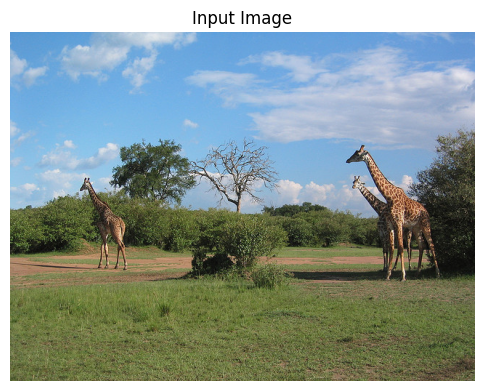

Active categories: ['person', 'sports ball']


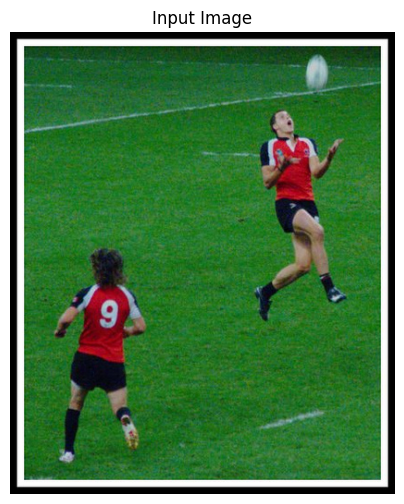

Active categories: ['person', 'airplane', 'handbag']


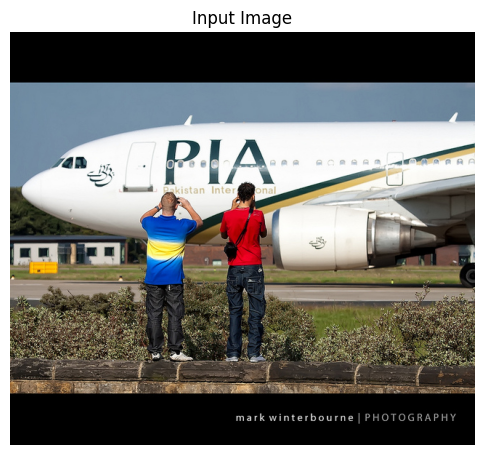

Active categories: ['pizza']


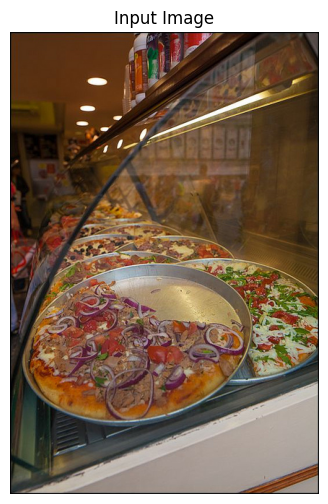

Active categories: ['stop sign']


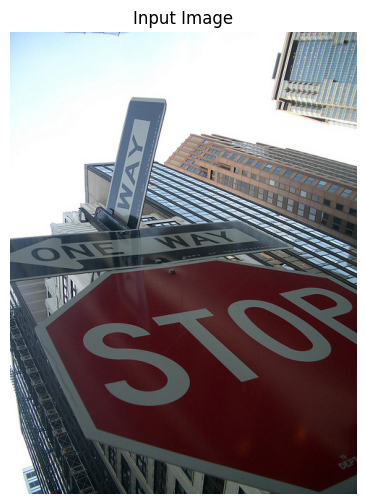

Active categories: ['person', 'car', 'skateboard']


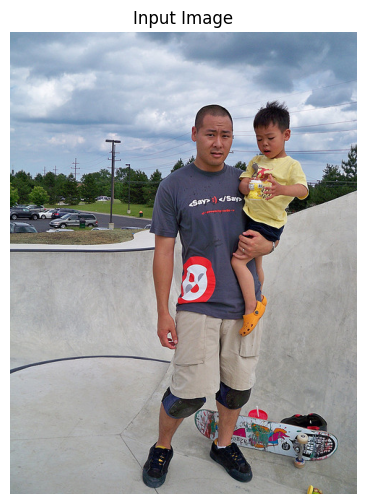

Active categories: ['person', 'skis']


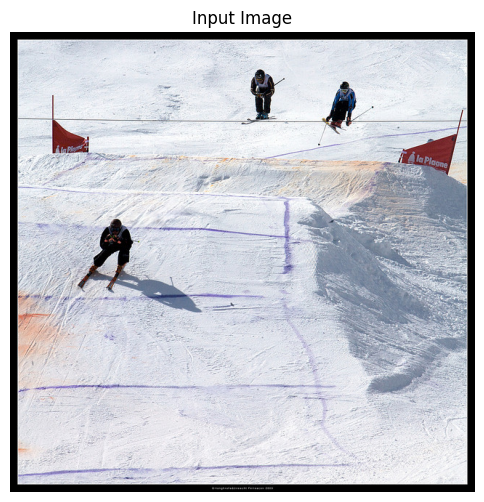

Active categories: ['person', 'spoon', 'bowl', 'dining table', 'book']


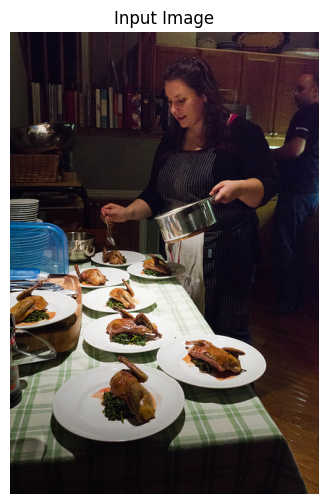

Active categories: ['person', 'cow', 'tie']


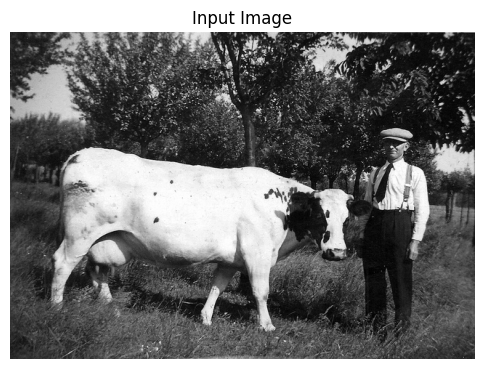

In [56]:
for x in range(11, 20):
    img_path = r"data/coco/" + coco_img[x]
    img = Image.open(img_path).convert("RGB")
    categories = coco_meta["category_list"]
    labels = coco_labels[x]

    active_cats = [cat for cat, val in zip(categories, labels) if val == 1]

    print("Active categories:", active_cats)
    import matplotlib.pyplot as plt
    # Show image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Image", fontsize=12)
    plt.show()


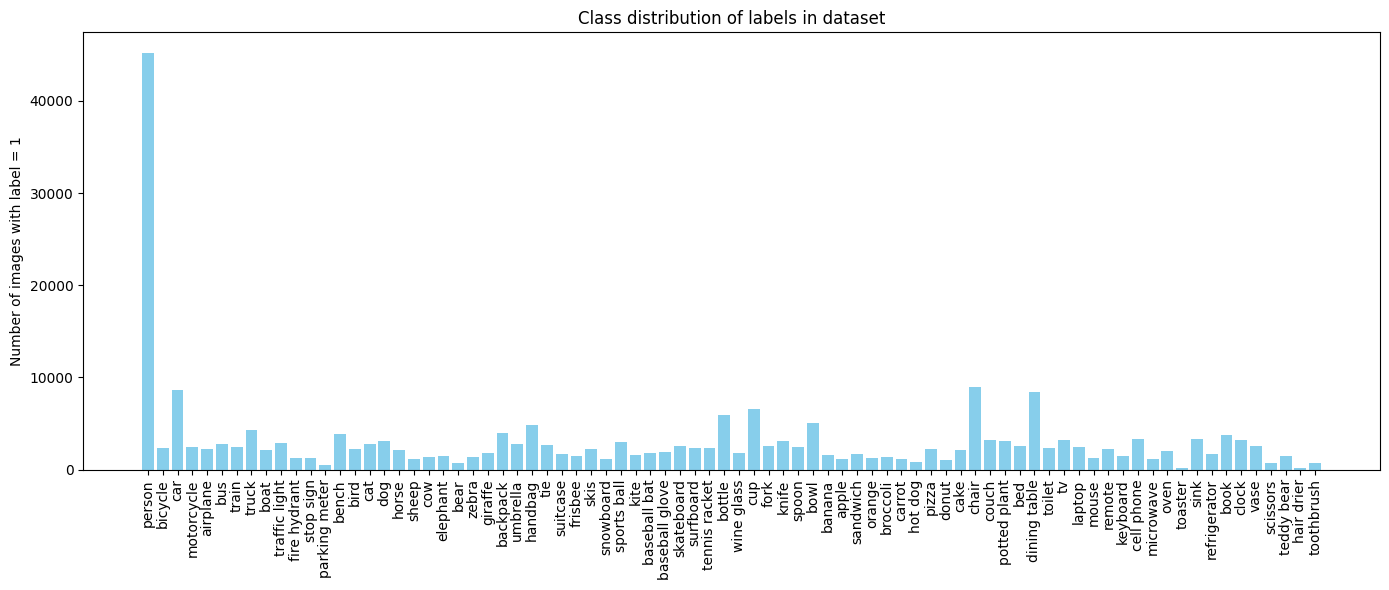

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# category list and labels
categories = coco_meta["category_list"]       # list of class names
labels = coco_labels                          # shape: (N, C), values 0/1

# count number of positives per class
class_counts = labels.sum(axis=0)             # shape: (C,)

# plot histogram
plt.figure(figsize=(14,6))
plt.bar(range(len(categories)), class_counts, color="skyblue")
plt.xticks(range(len(categories)), categories, rotation=90)
plt.ylabel("Number of images with label = 1")
plt.title("Class distribution of labels in dataset")
plt.tight_layout()
plt.show()



In [58]:
class_counts

array([45174.,  2287.,  8606.,  2442.,  2243.,  2791.,  2464.,  4321.,
        2098.,  2893.,  1205.,  1214.,   481.,  3844.,  2241.,  2818.,
        3041.,  2068.,  1105.,  1389.,  1518.,   668.,  1324.,  1798.,
        3924.,  2749.,  4861.,  2667.,  1631.,  1511.,  2209.,  1170.,
        2986.,  1625.,  1804.,  1884.,  2511.,  2343.,  2368.,  5968.,
        1771.,  6518.,  2537.,  3097.,  2493.,  5028.,  1618.,  1171.,
        1645.,  1216.,  1340.,  1186.,   821.,  2202.,  1062.,  2080.,
        8950.,  3170.,  3084.,  2539.,  8378.,  2317.,  3191.,  2475.,
        1290.,  2180.,  1471.,  3322.,  1089.,  2003.,   151.,  3291.,
        1671.,  3734.,  3159.,  2530.,   673.,  1510.,   128.,   700.])

In [59]:
dist = pd.DataFrame({
    'Class': categories,    
    'Count': class_counts
})

In [63]:
dist.Count.describe()

count       80.000000
mean      3012.937500
std       5065.558098
min        128.000000
25%       1450.500000
50%       2225.000000
75%       2999.750000
max      45174.000000
Name: Count, dtype: float64

In [64]:
dist.tail(40)

,Class,Count
40,wine glass,1771.0
41,cup,6518.0
42,fork,2537.0
43,knife,3097.0
44,spoon,2493.0
45,bowl,5028.0
46,banana,1618.0
47,apple,1171.0
48,sandwich,1645.0
49,orange,1216.0


In [65]:
dist.head(40)

,Class,Count
0,person,45174.0
1,bicycle,2287.0
2,car,8606.0
3,motorcycle,2442.0
4,airplane,2243.0
5,bus,2791.0
6,train,2464.0
7,truck,4321.0
8,boat,2098.0
9,traffic light,2893.0


In [7]:
import json
with open(r"data/coco/annotations/instances_val2014.json", 'r') as f:
    text = json.load(f)

In [8]:
text.keys()

dict_keys(['info', 'images', 'licenses', 'annotations', 'categories'])

In [9]:
text["info"]

{'description': 'COCO 2014 Dataset',
 'url': 'http://cocodataset.org',
 'version': '1.0',
 'year': 2014,
 'contributor': 'COCO Consortium',
 'date_created': '2017/09/01'}

In [11]:
text["categories"]

[{'supercategory': 'person', 'id': 1, 'name': 'person'},
 {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'},
 {'supercategory': 'vehicle', 'id': 3, 'name': 'car'},
 {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'},
 {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'},
 {'supercategory': 'vehicle', 'id': 6, 'name': 'bus'},
 {'supercategory': 'vehicle', 'id': 7, 'name': 'train'},
 {'supercategory': 'vehicle', 'id': 8, 'name': 'truck'},
 {'supercategory': 'vehicle', 'id': 9, 'name': 'boat'},
 {'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'},
 {'supercategory': 'outdoor', 'id': 11, 'name': 'fire hydrant'},
 {'supercategory': 'outdoor', 'id': 13, 'name': 'stop sign'},
 {'supercategory': 'outdoor', 'id': 14, 'name': 'parking meter'},
 {'supercategory': 'outdoor', 'id': 15, 'name': 'bench'},
 {'supercategory': 'animal', 'id': 16, 'name': 'bird'},
 {'supercategory': 'animal', 'id': 17, 'name': 'cat'},
 {'supercategory': 'animal', 'id': 18, 'name': 'dog'},

In [96]:
import numpy as np

In [97]:
ttt = np.load(r"data/coco/formatted_train_labels.npy")

In [98]:
ttt.shape

(82081, 91)

In [108]:
len(ttt[0])

91

In [106]:
fg = [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 0.]

In [107]:
len(fg)

92

In [99]:
import numpy as np
import json

# load data
labels = np.load(r"data/coco/formatted_train_labels.npy", allow_pickle=True)
images = np.load(r"data/coco/formatted_train_images.npy", allow_pickle=True)

with open("data/coco/annotations/formatted_metadata.json", "r") as f:
    meta = json.load(f)


In [115]:
x = 44

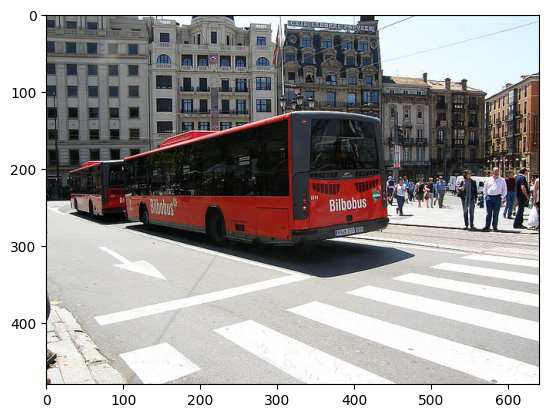

In [116]:
from PIL import Image
import matplotlib.pyplot as plt

row = labels[x]
with open(r"data/coco/" + images[x], "rb") as f:
    img = Image.open(f).convert("RGB")  

plt.imshow(img)

In [117]:
# split counts
num_categories = len(meta["category_list"])
num_supercats = len(meta["unique_supercategories"])

# find indices where label = 1
active_indices = np.where(row == 1)[0]

# map them
active_classes = []
for idx in active_indices:
    if idx < num_categories:
        active_classes.append(meta["category_list"][idx])
    else:
        super_idx = idx - num_categories
        active_classes.append(meta["unique_supercategories"][super_idx])

print(f"Labels for image {x}:", active_classes)


Labels for image 44: ['person', 'bus', 'backpack', 'handbag', 'accessory', 'vehicle']


In [51]:
labels.shape

(82081, 91)

In [ ]:
meta["category_list"]

['person',
 'bicycle',
 'car',
 'motorcycle',
 'airplane',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic light',
 'fire hydrant',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'backpack',
 'umbrella',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'couch',
 'potted plant',
 'bed',
 'dining table',
 'toilet',
 'tv',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'book',
 'clock',
 'vase',
 'scissors',
 'teddy bear',
 'hair drier',
 'toothbrush']

In [137]:
i2dname = {i: name for i, name in enumerate(meta["category_list"] + meta["unique_supercategories"])}

In [139]:
i2dname 

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [124]:
train_labels = np.load(r"data/coco/formatted_train_labels.npy")
val_labels = np.load(r"data/coco/formatted_val_labels.npy")


In [125]:
train_labels.shape, val_labels.shape

((82081, 91), (40137, 91))

In [127]:
all_labels = np.concat([train_labels, val_labels])
all_labels.shape

(122218, 91)

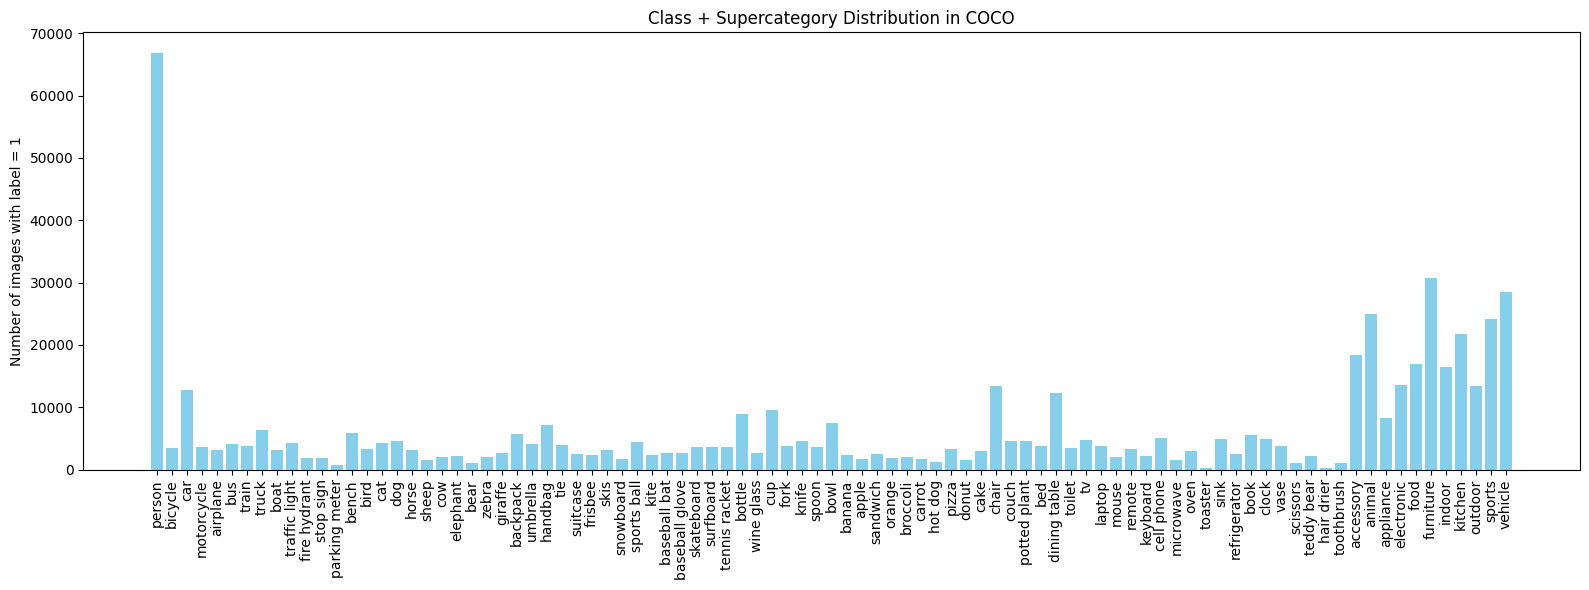

In [128]:
import numpy as np
import matplotlib.pyplot as plt
import json

# load metadata
with open("data/coco/annotations/formatted_metadata.json") as f:
    coco_meta = json.load(f)

num_classes = len(coco_meta["category_list"])              # 80 fine classes
num_supercats = len(coco_meta["unique_supercategories"])   # 11 supercategories

# make full category list (fine classes + supercategories)
all_categories = coco_meta["category_list"] + coco_meta["unique_supercategories"]

# sanity check
assert all_labels.shape[1] == num_classes + num_supercats

# count number of positives per class/supercat
class_counts = all_labels.sum(axis=0)

# plot histogram
plt.figure(figsize=(16,6))
plt.bar(range(len(all_categories)), class_counts, color="skyblue")
plt.xticks(range(len(all_categories)), all_categories, rotation=90)
plt.ylabel("Number of images with label = 1")
plt.title("Class + Supercategory Distribution in COCO")
plt.tight_layout()
plt.show()


In [134]:
import numpy as np
import json
from itertools import combinations

# --- Step 1: Load your data ---
# This section should remain as you have it
with open("data/coco/annotations/formatted_metadata.json") as f:
    coco_meta = json.load(f)

all_categories = coco_meta["category_list"] + coco_meta["unique_supercategories"]
num_all_categories = len(all_categories)

# NOTE: You must load your 'labels' matrix here.
# For this example, we use a more complex dummy matrix to show all rule types.
# Replace this with your actual 'labels' numpy array.
print("Loading your 'labels' matrix...")
# labels = np.load('path/to/your/coco_labels.npy') 
labels = all_labels.copy()  # Replace with your actual labels
all_categories = all_categories.copy()
num_all_categories = len(all_categories)
print("Label matrix loaded successfully.\n")

# --- Step 2: Pre-calculate counts for efficiency ---
# Total number of images each class appears in
class_counts = labels.sum(axis=0)

# Co-occurrence matrix: entry (i, j) is the number of times class i and j appear together
# This is much faster than looping. It's the dot product of the transposed label matrix with itself.
print("Calculating co-occurrence matrix...")
co_occurrence_matrix = labels.T @ labels
print("Calculation complete.\n")


# --- Step 3: Iterate through pairs and identify strict rules ---
equivalence_rules = []
implication_rules = []
exclusion_rules = []

for i, j in combinations(range(num_all_categories), 2):
    count_i = class_counts[i]
    count_j = class_counts[j]
    count_i_and_j = co_occurrence_matrix[i, j]

    class_i_name = all_categories[i]
    class_j_name = all_categories[j]

    # Skip pairs where one class never appears
    if count_i == 0 or count_j == 0:
        continue

    # Condition 1: 100% Exclusion
    if count_i_and_j == 0:
        rule1 = f"n{j} :- {i}" # if i, then not j
        rule2 = f"n{i} :- {j}" # if j, then not i
        exclusion_rules.extend([rule1, rule2])
        # print(f"Found EXCLUSION: '{class_i_name}' and '{class_j_name}'. Rules: {rule1}, {rule2}")

    # Condition 2: 100% Equivalence
    elif count_i == count_j and count_i == count_i_and_j:
        rule1 = f"{j} :- {i}" # if i, then j
        rule2 = f"{i} :- {j}" # if j, then i
        equivalence_rules.extend([rule1, rule2])
        # print(f"Found EQUIVALENCE: '{class_i_name}' <-> '{class_j_name}'. Rules: {rule1}, {rule2}")
        
    # Condition 3: 100% Implication (A -> B)
    elif count_i == count_i_and_j:
        rule = f"{j} :- {i}" # if i, then j
        implication_rules.append(rule)
        # print(f"Found IMPLICATION: '{class_i_name}' -> '{class_j_name}'. Rule: {rule}")

    # Condition 4: 100% Implication (B -> A)
    elif count_j == count_i_and_j:
        rule = f"{i} :- {j}" # if j, then i
        implication_rules.append(rule)
        # print(f"Found IMPLICATION: '{class_j_name}' -> '{class_i_name}'. Rule: {rule}")


# --- Step 4: Display the results ---
print("--- ✅ 100% Equivalence Rules (A <-> B) ---")
print(f"Found {len(equivalence_rules)} rules.")
print(equivalence_rules)

print("\n--- 👉 100% Implication Rules (A -> B) ---")
print(f"Found {len(implication_rules)} rules.")
print(implication_rules)

print("\n--- ❌ 100% Exclusion Rules (A -> ¬B) ---")
print(f"Found {len(exclusion_rules)} rules.")
print(exclusion_rules)

# You can save all rules to one file
# all_rules = equivalence_rules + implication_rules + exclusion_rules
# with open("strict_rules.txt", "w") as f:
#     for rule in all_rules:
#         f.write(rule + "\n")

Loading your 'labels' matrix...
Label matrix loaded successfully.

Calculating co-occurrence matrix...
Calculation complete.

--- ✅ 100% Equivalence Rules (A <-> B) ---
Found 0 rules.
[]

--- 👉 100% Implication Rules (A -> B) ---
Found 79 rules.
['90 :- 1', '90 :- 2', '90 :- 3', '90 :- 4', '90 :- 5', '90 :- 6', '90 :- 7', '90 :- 8', '88 :- 9', '88 :- 10', '88 :- 11', '88 :- 12', '88 :- 13', '81 :- 14', '81 :- 15', '81 :- 16', '81 :- 17', '81 :- 18', '81 :- 19', '81 :- 20', '81 :- 21', '81 :- 22', '81 :- 23', '80 :- 24', '80 :- 25', '80 :- 26', '80 :- 27', '80 :- 28', '89 :- 29', '89 :- 30', '89 :- 31', '89 :- 32', '89 :- 33', '89 :- 34', '89 :- 35', '89 :- 36', '89 :- 37', '89 :- 38', '87 :- 39', '87 :- 40', '87 :- 41', '87 :- 42', '87 :- 43', '87 :- 44', '87 :- 45', '84 :- 46', '84 :- 47', '84 :- 48', '84 :- 49', '84 :- 50', '84 :- 51', '84 :- 52', '84 :- 53', '84 :- 54', '84 :- 55', '85 :- 56', '85 :- 57', '85 :- 58', '85 :- 59', '85 :- 60', '85 :- 61', '83 :- 62', '83 :- 63', '83 :-

In [135]:
implication_rules

['90 :- 1',
 '90 :- 2',
 '90 :- 3',
 '90 :- 4',
 '90 :- 5',
 '90 :- 6',
 '90 :- 7',
 '90 :- 8',
 '88 :- 9',
 '88 :- 10',
 '88 :- 11',
 '88 :- 12',
 '88 :- 13',
 '81 :- 14',
 '81 :- 15',
 '81 :- 16',
 '81 :- 17',
 '81 :- 18',
 '81 :- 19',
 '81 :- 20',
 '81 :- 21',
 '81 :- 22',
 '81 :- 23',
 '80 :- 24',
 '80 :- 25',
 '80 :- 26',
 '80 :- 27',
 '80 :- 28',
 '89 :- 29',
 '89 :- 30',
 '89 :- 31',
 '89 :- 32',
 '89 :- 33',
 '89 :- 34',
 '89 :- 35',
 '89 :- 36',
 '89 :- 37',
 '89 :- 38',
 '87 :- 39',
 '87 :- 40',
 '87 :- 41',
 '87 :- 42',
 '87 :- 43',
 '87 :- 44',
 '87 :- 45',
 '84 :- 46',
 '84 :- 47',
 '84 :- 48',
 '84 :- 49',
 '84 :- 50',
 '84 :- 51',
 '84 :- 52',
 '84 :- 53',
 '84 :- 54',
 '84 :- 55',
 '85 :- 56',
 '85 :- 57',
 '85 :- 58',
 '85 :- 59',
 '85 :- 60',
 '85 :- 61',
 '83 :- 62',
 '83 :- 63',
 '83 :- 64',
 '83 :- 65',
 '83 :- 66',
 '83 :- 67',
 '82 :- 68',
 '82 :- 69',
 '82 :- 70',
 '82 :- 71',
 '82 :- 72',
 '86 :- 73',
 '86 :- 74',
 '86 :- 75',
 '86 :- 76',
 '86 :- 77',
 '86 :- 

In [56]:
import pandas as pd

In [121]:
all_categories

['person',
 'bicycle',
 'car',
 'motorcycle',
 'airplane',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic light',
 'fire hydrant',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'backpack',
 'umbrella',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'couch',
 'potted plant',
 'bed',
 'dining table',
 'toilet',
 'tv',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'book',
 'clock',
 'vase',
 'scissors',
 'teddy bear',
 'hair drier',
 'toothbrush',
 'accessory',
 'animal',
 'appliance',
 'electronic',
 'foo

In [119]:
df = pd.DataFrame({
    'Class': all_categories,    
    'Count': class_counts
})

In [120]:
df.tail(40)

,Class,Count
51,carrot,1186.0
52,hot dog,821.0
53,pizza,2202.0
54,donut,1062.0
55,cake,2080.0
56,chair,8950.0
57,couch,3170.0
58,potted plant,3084.0
59,bed,2539.0
60,dining table,8378.0


In [61]:
supercats = coco_meta["unique_supercategories"]
supercat_to_id = {sc: i+20 for i, sc in enumerate(supercats)}  # start from 20 like your example


In [62]:
cat_list = coco_meta["category_list"]               # 80 fine class names
supercat_list = coco_meta["supercategory_list"]     # 80 aligned supercategories

cat_to_id = {name: idx for idx, name in enumerate(cat_list)}   # category name → index

In [63]:
output_lines = []
for cat_idx, supercat in enumerate(supercat_list):
    if supercat in supercat_to_id:   # skip "person" if excluded
        super_id = supercat_to_id[supercat]
        line = f"{super_id} :- {cat_idx}"
        output_lines.append(line)

with open("coco_super_to_cat.txt", "w") as f:
    f.write("\n".join(output_lines))